# The Model-Building Cycle: five classifiers, three split ratios, three case studies

01 Core Python · 02 Pandas · 03 Cleaning · 04 Transformation · 05 Feature Engineering · 06 Regression · **▶ 07 Model Prep** · 08 Case Studies

`07_Model_Preparation/03_model_building_cycle_case_studies.ipynb`

---

### In one paragraph (no jargon)

A single train/test split is one roll of the dice, and on a small dataset the result can look quite different depending on how that roll landed. This notebook trains five classifiers spanning the main families, Logistic Regression, a Decision Tree, K-Nearest Neighbors, a Random Forest, and Naive Bayes, on three different split ratios (80/20, 70/30, 60/40), across the same three business problems as the course demo: predicting manufacturing equipment failure, hospital readmission, and retail customer churn. The question each comparison answers is simple: does the best model stay the best model once the split ratio changes?

### After this notebook you can

- Train and compare several classifiers at once instead of picking one and hoping
- Run the same comparison across several train/test ratios to see how stable the result is
- Read a compact, colour-graded comparison table instead of a wall of separate outputs
- Judge a model on both its best result and its average reliability across splits

**Assumed knowledge:** `07_Model_Preparation/02_train_validation_test_splitting.ipynb`

### What's inside

1. Setup
2. The comparison engine
3. Case Study 1: Manufacturing (equipment failure)
4. Case Study 2: Healthcare (patient readmission)
5. Case Study 3: Retail (customer churn)
6. All three case studies compared
7. Exam quick-reference

---

> **▶ Runs on its own.** The next cell is the only setup you need. It imports the
> libraries and loads the data. If the `datasets/` folder isn't where it expects,
> it rebuilds an equivalent dataset in memory, so **every cell below still runs**,
> which is handy if you copy this single `.ipynb` somewhere else.
>
> **▶ Reading the cells.** Code comments explain *what the line does*; the text
> blocks explain *why you'd do it*. Look for these markers:
> `# WHAT:` a plain-English translation · `# WHY:` the reason it matters ·
> `# 🔧 CHANGE THIS:` the knob to turn when the exam question differs ·
> **⚡ Beyond the syllabus** = optional, higher-mark techniques.

### Where this notebook came from

This extends a template your course provided, **`Model_building_demo.ipynb`**, which walked through building
and comparing two classifiers (Logistic Regression and a Decision Tree) on loan default data, using a single
80/20 train/test split. This version asks a sharper question: **does the winning model change if the split
ratio changes?** Five classifiers are trained on three different split ratios (80/20, 70/30, 60/40) across the
same three business problems as before: predicting manufacturing equipment failure, hospital readmission, and
retail customer churn.

### Jargon buster

| Term | Plain English |
|---|---|
| Classifier | A model that predicts a category (Yes/No, Failure/OK) rather than a number. |
| Logistic Regression | Draws the best straight-line boundary between the two classes. Fast, and the coefficients are easy to explain. |
| Decision Tree | Asks a sequence of yes/no questions about the features and follows the answers to a prediction. |
| K-Nearest Neighbors (KNN) | Finds the k most similar rows already seen and predicts whatever most of them turned out to be. |
| Random Forest | Builds many different decision trees on random slices of the data and lets them vote. Usually sturdier than any single tree. |
| Naive Bayes | Uses probability, assuming each feature contributes independently. Fast and a solid baseline even when that assumption is not quite true. |
| Split ratio (e.g. 80/20) | How much of the data becomes the training set versus the test set. 80/20 means 80% trains the model, 20% tests it. |
| `stratify=y` | Keeps the same proportion of each class in both the training and test sets. |
| Accuracy | The fraction of test predictions that were correct. |
| Overfitting | The model memorised the training rows instead of learning the underlying pattern: strong on training data, weak on new data. |

In [1]:
# =============================================================================
# SETUP — run this cell first. It is the only cell with dependencies.
# =============================================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)


def find_datasets_folder(start=None):
    """Walk upwards from this notebook looking for the shared `datasets/` folder."""
    here = os.path.abspath(start or os.getcwd())
    for _ in range(6):
        candidate = os.path.join(here, 'datasets')
        if os.path.isdir(candidate):
            return candidate
        parent = os.path.dirname(here)
        if parent == here:
            break
        here = parent
    return None


def load_data(filename, rebuild=None, **read_kwargs):
    """Load `filename` from the shared datasets folder, or rebuild it in memory."""
    folder = find_datasets_folder()
    if folder:
        path = os.path.join(folder, filename)
        if os.path.exists(path):
            print(f"Loaded '{filename}' from {folder}")
            return pd.read_csv(path, **read_kwargs)
    if rebuild is None:
        raise FileNotFoundError(f"Could not find {filename} and no fallback was supplied.")
    print(f"'{filename}' not found on disk, so rebuilding an equivalent dataset in memory.")
    return rebuild()

def rebuild_manufacturing():
    """Exact copy of Manufacturing.csv, embedded so this notebook never needs the file."""
    import io
    csv_text = """Temperature_C,Vibration_mm_s,Days_Since_Maintenance,Machine_Load_Pct,Failure
90,5.3,186,63,Yes
68,6.6,49,61,No
62,9.6,103,90,Yes
69,8.7,50,71,No
74,5.0,153,78,No
89,9.9,122,96,Yes
75,6.3,46,69,No
61,8.1,39,90,Yes
71,3.4,36,63,No
81,3.3,23,60,No
89,4.1,165,61,Yes
86,9.6,161,71,Yes
96,7.9,84,78,No
65,9.3,36,60,No
92,7.7,67,83,Yes
60,5.8,96,92,No
79,6.6,111,79,No
68,7.2,103,64,Yes
65,9.4,125,92,Yes
83,6.0,125,62,No
69,9.6,126,79,No
79,7.4,105,98,Yes
68,9.1,95,74,No
63,6.5,179,77,No
87,8.0,159,69,Yes
74,5.2,147,72,No
84,6.7,29,69,No
84,4.2,117,61,No
94,3.3,169,88,Yes
74,2.8,124,75,Yes
66,8.1,52,98,Yes
82,6.2,106,74,No
94,9.7,113,90,Yes
95,9.2,184,80,Yes
91,5.6,113,84,No
84,10.3,58,60,No
72,7.2,38,93,No
73,8.6,137,65,No
59,5.8,187,97,No
65,4.1,114,68,No"""
    return pd.read_csv(io.StringIO(csv_text))


def rebuild_healthcare():
    """Exact copy of Healthcare.csv, embedded so this notebook never needs the file."""
    import io
    csv_text = """Age,Systolic_BP,Blood_Sugar,Comorbidities,Readmitted
82,145,131,3,No
63,123,103,4,No
66,177,177,3,Yes
79,118,168,4,Yes
60,178,94,3,No
72,157,129,4,Yes
75,114,174,6,Yes
38,108,164,1,Yes
28,143,150,3,No
43,108,142,3,No
42,117,79,2,No
78,149,153,1,No
80,188,125,0,No
25,145,84,2,No
55,174,100,5,No
75,183,132,0,No
33,175,152,2,Yes
73,159,128,6,Yes
32,142,139,6,No
53,149,167,1,No
74,127,147,0,No
43,147,113,4,Yes
45,137,143,0,No
41,126,138,2,No
68,190,86,3,No
40,106,81,6,No
85,113,144,0,No
52,121,116,4,No
54,188,138,3,Yes
55,164,109,0,No
60,180,98,5,No
58,122,90,5,No
56,167,115,3,No
85,136,161,6,Yes
74,147,117,4,Yes
73,105,115,6,Yes
67,158,135,6,No
62,176,178,3,Yes
45,162,116,1,No
85,118,137,1,No"""
    return pd.read_csv(io.StringIO(csv_text))


def rebuild_retail():
    """Exact copy of Retail.csv, embedded so this notebook never needs the file."""
    import io
    csv_text = """Days_Since_Purchase,Purchases_6M,Avg_Bill_Rs,Campaign_Response,Churn
141,14,3109,0,No
173,4,3297,0,Yes
51,9,889,1,No
41,15,3106,1,No
144,11,1054,1,No
150,6,1752,0,Yes
95,2,971,0,No
31,17,1160,1,No
151,4,2193,1,Yes
95,9,2117,1,No
31,12,1808,0,No
28,6,2057,0,No
77,9,2006,0,No
126,5,2480,1,Yes
76,15,2631,0,No
153,11,1857,0,No
6,4,3042,0,No
79,6,2665,1,No
97,12,2208,1,No
173,12,1055,1,Yes
46,6,3283,1,No
150,3,1422,0,Yes
17,3,1726,0,No
64,5,3079,0,No
136,14,3353,1,No
106,15,3761,0,No
170,6,3249,1,Yes
137,11,3205,0,No
165,9,2990,1,No
150,5,3314,1,Yes
28,10,2437,0,No
169,3,3167,1,Yes
153,9,1455,0,Yes
30,3,2116,1,No
177,5,3161,0,Yes
136,5,2990,0,Yes
60,1,2004,0,No
29,7,2493,1,No
73,13,1840,1,No
164,12,2097,0,No"""
    return pd.read_csv(io.StringIO(csv_text))


print("Setup complete. pandas", pd.__version__, "| scikit-learn ready.")

Setup complete. pandas 3.0.2 | scikit-learn ready.


In [2]:
# =============================================================================
# THE COMPARISON ENGINE
# =============================================================================
# WHAT: one function that trains five classifiers on three train/test ratios
#       and returns a single tidy table, instead of one output per combination.
# WHY a function at all: it turns "compare everything" into a repeatable method
#       you can point at any dataset, not something tied to one file's column
#       names, which is exactly what an exam wants to see demonstrated.

SPLITS = [('80/20', 0.20), ('70/30', 0.30), ('60/40', 0.40)]   # (label, test_size)


def build_models():
    """Fresh, unfitted classifiers spanning the main families: linear, tree,
    distance-based, ensemble, probabilistic. Called fresh for every split so
    no model ever carries state from a previous fit.
    """
    return {
        'Logistic Regression': LogisticRegression(max_iter=1000),
        'Decision Tree':       DecisionTreeClassifier(max_depth=3, random_state=42),
        'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
        'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
        'Naive Bayes':         GaussianNB(),
    }


def compare_across_splits(data, feature_cols, target_col, label, random_state=1):
    """Train every model in build_models() at every ratio in SPLITS.

    Prints exactly ONE styled table and ONE chart for the whole comparison,
    not one output per model or per split.
    """
    X, y = data[feature_cols], data[target_col]

    rows = []
    for split_name, test_size in SPLITS:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state, stratify=y)
        for model_name, model in build_models().items():
            model.fit(X_train, y_train)
            pred = model.predict(X_test)
            rows.append({'Split': split_name, 'Model': model_name,
                        'Accuracy': accuracy_score(y_test, pred)})

    long = pd.DataFrame(rows)
    wide = long.pivot(index='Model', columns='Split', values='Accuracy')
    wide = wide[[name for name, _ in SPLITS]]          # fix column order: 80/20, 70/30, 60/40

    print(f"{label}  ({data.shape[0]} rows total)")
    display(wide.style.format('{:.1%}')
                      .background_gradient(cmap='Greens', axis=None)
                      .set_caption('Accuracy by model and split'))

    stacked = wide.stack()
    best_model, best_split = stacked.idxmax()
    winners = wide.idxmax(axis=0)                      # which model wins at each split
    avg_acc = wide.mean(axis=1).sort_values(ascending=False)

    print(f"Best single result   : {best_model} at {best_split}  ({stacked.max():.1%})")
    print(f"Most reliable overall: {avg_acc.index[0]}  (averages {avg_acc.iloc[0]:.1%} across all three splits)")
    if winners.nunique() == 1:
        print(f"Same winner at every split ratio: {winners.iloc[0]}.")
    else:
        changes = ", ".join(f"{s} -> {m}" for s, m in winners.items())
        print(f"The winner changes with the split ratio ({changes}).")
        print("On a 40-row dataset that swing is expected. It is not a sign either model is wrong,")
        print("it reflects how few test rows there are to judge by, especially at 80/20.")

    fig, ax = plt.subplots(figsize=(6.5, 3.6))
    for model_name in wide.index:
        ax.plot([name for name, _ in SPLITS], wide.loc[model_name], marker='o', label=model_name)
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0, 1.05)
    ax.set_title(f'{label}: accuracy as the split ratio changes')
    ax.legend(fontsize=8, loc='center left', bbox_to_anchor=(1.0, 0.5))
    plt.tight_layout()
    plt.show()

    return wide, avg_acc

---
## Case Study 1: Manufacturing, will this machine fail?

Given a machine's temperature, vibration, days since its last maintenance, and current load, will it fail
before the next scheduled service? Catching this early is the difference between a planned maintenance visit
and an unplanned production stoppage.

Loaded 'Manufacturing.csv' from /home/claude/work/build/Python-BDA-Complete-Notes/datasets


,Temperature_C,Vibration_mm_s,Days_Since_Maintenance,Machine_Load_Pct,Failure
0,90,5.3,186,63,Yes
1,68,6.6,49,61,No
2,62,9.6,103,90,Yes
3,69,8.7,50,71,No
4,74,5.0,153,78,No


Manufacturing: Equipment Failure  (40 rows total)


Split,80/20,70/30,60/40
Model,,,
Decision Tree,87.5%,83.3%,81.2%
K-Nearest Neighbors,50.0%,58.3%,62.5%
Logistic Regression,62.5%,58.3%,68.8%
Naive Bayes,75.0%,50.0%,62.5%
Random Forest,87.5%,66.7%,81.2%


Best single result   : Decision Tree at 80/20  (87.5%)
Most reliable overall: Decision Tree  (averages 84.0% across all three splits)
Same winner at every split ratio: Decision Tree.


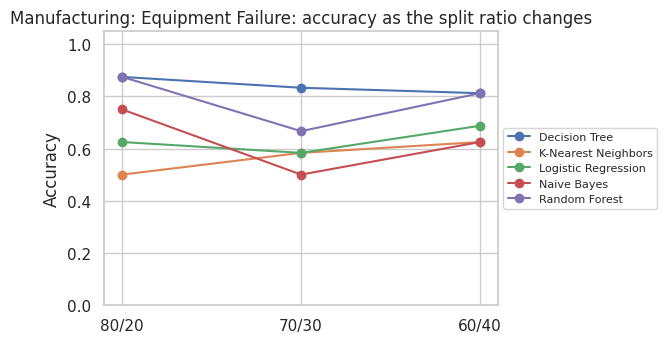

In [3]:
manufacturing = load_data('Manufacturing.csv', rebuild=rebuild_manufacturing)
display(manufacturing.head())

manufacturing_wide, manufacturing_avg = compare_across_splits(
    manufacturing,
    feature_cols=['Temperature_C', 'Vibration_mm_s', 'Days_Since_Maintenance', 'Machine_Load_Pct'],
    target_col='Failure',
    label='Manufacturing: Equipment Failure')

---
## Case Study 2: Healthcare, will this patient be readmitted?

Given a patient's age, blood pressure, blood sugar, and number of comorbidities at discharge, will they be
readmitted? Hospitals are frequently measured, and funded, on readmission rates, so flagging high-risk
patients for a follow-up call is a genuinely actionable prediction.

Loaded 'Healthcare.csv' from /home/claude/work/build/Python-BDA-Complete-Notes/datasets


,Age,Systolic_BP,Blood_Sugar,Comorbidities,Readmitted
0,82,145,131,3,No
1,63,123,103,4,No
2,66,177,177,3,Yes
3,79,118,168,4,Yes
4,60,178,94,3,No


Healthcare: Patient Readmission  (40 rows total)


Split,80/20,70/30,60/40
Model,,,
Decision Tree,75.0%,75.0%,81.2%
K-Nearest Neighbors,75.0%,75.0%,75.0%
Logistic Regression,62.5%,66.7%,81.2%
Naive Bayes,62.5%,75.0%,81.2%
Random Forest,87.5%,83.3%,87.5%


Best single result   : Random Forest at 80/20  (87.5%)
Most reliable overall: Random Forest  (averages 86.1% across all three splits)
Same winner at every split ratio: Random Forest.


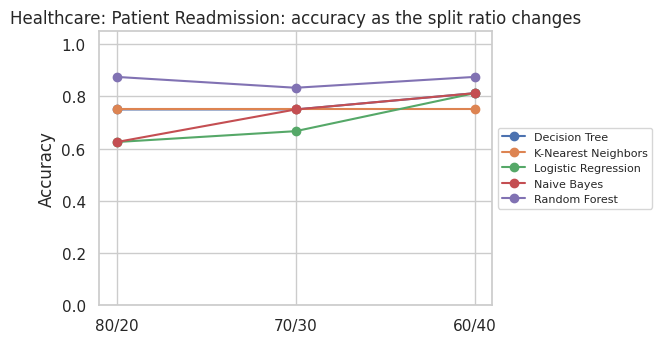

In [4]:
healthcare = load_data('Healthcare.csv', rebuild=rebuild_healthcare)
display(healthcare.head())

healthcare_wide, healthcare_avg = compare_across_splits(
    healthcare,
    feature_cols=['Age', 'Systolic_BP', 'Blood_Sugar', 'Comorbidities'],
    target_col='Readmitted',
    label='Healthcare: Patient Readmission')

---
## Case Study 3: Retail, will this customer churn?

Given how long since a customer's last purchase, how often they bought in the last six months, their average
bill, and whether they responded to a marketing campaign, will they churn? An early warning here lets the
business step in with a retention offer before the customer is gone rather than after.

Loaded 'Retail.csv' from /home/claude/work/build/Python-BDA-Complete-Notes/datasets


,Days_Since_Purchase,Purchases_6M,Avg_Bill_Rs,Campaign_Response,Churn
0,141,14,3109,0,No
1,173,4,3297,0,Yes
2,51,9,889,1,No
3,41,15,3106,1,No
4,144,11,1054,1,No


Retail: Customer Churn  (40 rows total)


Split,80/20,70/30,60/40
Model,,,
Decision Tree,100.0%,83.3%,87.5%
K-Nearest Neighbors,75.0%,66.7%,68.8%
Logistic Regression,87.5%,83.3%,81.2%
Naive Bayes,87.5%,83.3%,87.5%
Random Forest,87.5%,83.3%,87.5%


Best single result   : Decision Tree at 80/20  (100.0%)
Most reliable overall: Decision Tree  (averages 90.3% across all three splits)
Same winner at every split ratio: Decision Tree.


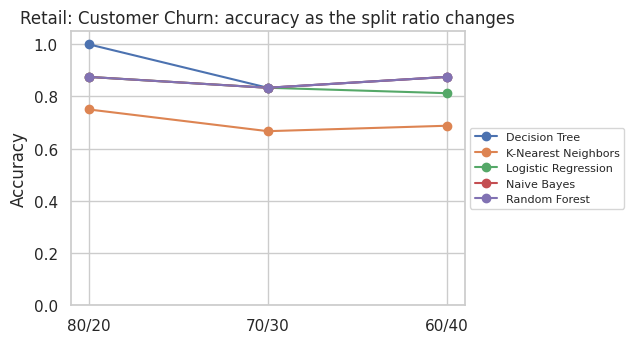

In [5]:
retail = load_data('Retail.csv', rebuild=rebuild_retail)
display(retail.head())

retail_wide, retail_avg = compare_across_splits(
    retail,
    feature_cols=['Days_Since_Purchase', 'Purchases_6M', 'Avg_Bill_Rs', 'Campaign_Response'],
    target_col='Churn',
    label='Retail: Customer Churn')

## All three case studies compared

In [6]:
overview_rows = []
for case_label, wide, avg in [('Manufacturing', manufacturing_wide, manufacturing_avg),
                              ('Healthcare', healthcare_wide, healthcare_avg),
                              ('Retail', retail_wide, retail_avg)]:
    stacked = wide.stack()
    best_model, best_split = stacked.idxmax()
    overview_rows.append({
        'Dataset':              case_label,
        'Best combination':     f'{best_model} @ {best_split}',
        'Best accuracy':        stacked.max(),
        'Most reliable model':  avg.index[0],
        'Its average accuracy': avg.iloc[0],
    })

overview = pd.DataFrame(overview_rows).set_index('Dataset')
display(overview.style.format({'Best accuracy': '{:.1%}', 'Its average accuracy': '{:.1%}'})
                      .set_caption('Best single result vs most reliable model, per case study'))

print("Accuracy is the metric used throughout, matching the course demo's own evaluation.")
print("For a target where missing a positive case is costlier than a false alarm, such as a")
print("genuine equipment failure or a readmission, precision and recall would be the next")
print("check; see 08_Case_Studies for that fuller treatment.")

,Best combination,Best accuracy,Most reliable model,Its average accuracy
Dataset,,,,
Manufacturing,Decision Tree @ 80/20,87.5%,Decision Tree,84.0%
Healthcare,Random Forest @ 80/20,87.5%,Random Forest,86.1%
Retail,Decision Tree @ 80/20,100.0%,Decision Tree,90.3%


Accuracy is the metric used throughout, matching the course demo's own evaluation.
For a target where missing a positive case is costlier than a false alarm, such as a
genuine equipment failure or a readmission, precision and recall would be the next
check; see 08_Case_Studies for that fuller treatment.


---

## Exam quick-reference

| To do this | Write this |
|---|---|
| Fresh model instances | `build_models()` (a dict, called once per split) |
| Stratified split at a given ratio | `train_test_split(X, y, test_size=0.30, stratify=y)` |
| Fit and predict | `model.fit(X_train, y_train)`, `model.predict(X_test)` |
| Accuracy | `accuracy_score(y_test, pred)` |
| Long to wide table | `df.pivot(index='Model', columns='Split', values='Accuracy')` |
| Fix column order | `wide[['80/20', '70/30', '60/40']]` |
| Colour-graded table | `wide.style.format('{:.1%}').background_gradient(cmap='Greens')` |
| Best single cell | `wide.stack().idxmax()` |
| Winner per column | `wide.idxmax(axis=0)` |
| Average across splits | `wide.mean(axis=1)` |
| KNN | `KNeighborsClassifier(n_neighbors=5)` |
| Random Forest | `RandomForestClassifier(n_estimators=100, random_state=42)` |
| Naive Bayes | `GaussianNB()` |

### Adapting this in the exam

- Different dataset? Only the `feature_cols` and `target_col` arguments to `compare_across_splits` change.
- Asked for different split ratios? Edit the `SPLITS` list at the top of the comparison engine; everything downstream adapts automatically.
- Asked to add another classifier? Add one line to `build_models()`; it is picked up by every split and every case study with no other change.
- Asked which model to recommend? Report both numbers from the overview table: the best single result, and the most reliable one on average. They are not always the same model, and saying so is itself the finding.

### Traps that cost marks

- A smaller training fraction (60/40) leaves less data to learn from, so accuracy can genuinely fall there even for a good model. That is a real trade-off, not a bug.
- A larger test fraction also means fewer test rows are wrong per percentage point, so its accuracy reading is actually the more stable one of the three despite training on less data. Small test sets swing more per row, not less.
- Rebuilding `build_models()` fresh for every split matters. Reusing a fitted model across splits would silently mix training data between them.
- `wide.stack()` orders by (index, columns), meaning (Model, Split). Unpacking it the other way round silently swaps the two in your printed sentence.
- `background_gradient(axis=None)` colours the whole grid on one shared scale, which is what makes columns comparable. Leaving `axis` at its default colours each column separately and can make a mediocre model look like the best one in its own column.
- Accuracy alone hides *which* mistakes a model makes. It is the right first metric, not the only one worth knowing; see the note at the end of the overview table.